<a href="https://colab.research.google.com/github/khanglam2110/python_project/blob/main/VN_30_Spillover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🚀 LOAD & CLEAN DATA

In [3]:
# Import Libraries
from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import networkx as nx
from sklearn.metrics import silhouette_score

# Đọc và xử lý Data
# 1. Đọc dữ liệu
df = pd.read_excel('VN30_preprocessed-2.xlsx')

# 2. Chuyển dữ liệu kiểu ngày, bỏ .csv
df['Date'] = pd.to_datetime(df['Date'])
df["Ticker"] = (
    df["Source.Name"]
    .str.replace(".csv", "", regex=False) # bỏ .csv
    .str.replace("E6", "M", regex=False) # sửa lỗi encoding
)

# 3. Giữ lại các cột cần thiết
# Fix: Include 'Ticker' in the columns to keep
df = df[['Source.Name', 'Date', 'Price', 'Ticker']]

# 4. Pivot sang dạng wide
price_df = df.pivot(index='Date', columns='Ticker', values='Price').sort_index()

# 5. Sắp xếp theo ngày
price_df = price_df.sort_index()

# 6. Tính log return (để loại bỏ xu hướng)
returns = np.log(price_df / price_df.shift(1)).dropna()

print("Dữ liệu returns:")
print(returns.head())

Dữ liệu returns:
Ticker           ACB       BCM       BID       CTG       DGC       FPT  \
Date                                                                     
2021-03-26  0.012403  0.021284 -0.003556 -0.008923 -0.005985 -0.006549   
2021-03-29  0.016807  0.008728  0.010631  0.024035  0.051021  0.019519   
2021-03-30  0.009050  0.005214  0.007028  0.009953 -0.028819 -0.006464   
2021-03-31  0.000000 -0.005214  0.002330 -0.006208 -0.013278  0.007751   
2021-04-01  0.016382 -0.001732  0.023015  0.022167  0.023442  0.025414   

Ticker           GAS       GVR       HDB       HPG  ...       TCB       TPB  \
Date                                                ...                       
2021-03-26 -0.012257 -0.010959  0.005842  0.026321  ...  0.001270 -0.007460   
2021-03-29  0.003357  0.019958  0.009662  0.002160  ...  0.003800  0.025879   
2021-03-30  0.001117  0.012493  0.007663  0.003232  ...  0.012563  0.014493   
2021-03-31  0.001114 -0.014301  0.007605  0.007510  ...  0.008701  0.

## 🔥 PIVOT → PRICE MATRIX

In [4]:
price_df = df.pivot(index="Date", columns="Ticker", values="Price")

returns = np.log(price_df / price_df.shift(1)).dropna()

returns = returns.clip(lower=-0.2, upper=0.2)

## 🧠 CHECK STATIONARITY (ADF)

In [5]:
from statsmodels.tsa.stattools import adfuller

def adf_check(data, alpha=0.05):
  print("\n🔍 ADF Test Results:")

  stationary = []
  non_stationary = []

  for col in data.columns:
    result = adfuller(data[col].dropna(), autolag='AIC')
    p_value = result[1]

    if p_value < alpha:
      stationary.append(col)
    else:
      non_stationary.append((col, p_value))
  # print warning
  if non_stationary:
    print("\n⚠️ Non-stationary series:")
    for col, p in non_stationary:
      print(f" -{col}: p-value = {p:.4f}")

  # summary
  print(f"\n📊 Stationary: {len(stationary)}/{data.shape[1]}")

  if len(non_stationary) == 0:
    print("🎉 All series are stationary. Ready for VAR!")
  else:
    print("⚠️ Some series are not stationary. VAR results may be affected.")

  return stationary, non_stationary

stationary, non_stationary = adf_check(returns)


🔍 ADF Test Results:

📊 Stationary: 30/30
🎉 All series are stationary. Ready for VAR!


## 🔥 CHỌN LAG & FIT VAR MODEL

In [6]:
# 1. Chọn Lag

model = VAR(returns)

lag_order = model.select_order(maxlags=10)
print(lag_order.summary())

# 2. Chọn p (lag tối ưu)

p = lag_order.aic

p = max(1, p)

print(f"Using Lag: {p}")

var_model = model.fit(p)

print(f"Optimal lag (AIC): {p}")

# 3. FIT VAR

var_model = model.fit(p)

print(var_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -247.4*     -247.2* 3.722e-108*     -247.3*
1       -247.1      -243.0  4.817e-108      -245.5
2       -246.7      -238.6  7.160e-108      -243.6
3       -246.1      -234.0  1.295e-107      -241.5
4       -245.6      -229.4  2.292e-107      -239.5
5       -245.1      -224.9  3.828e-107      -237.5
6       -244.7      -220.5  5.721e-107      -235.6
7       -244.3      -216.1  8.727e-107      -233.7
8       -244.0      -211.8  1.255e-106      -231.9
9       -243.7      -207.5  1.960e-106      -230.0
10      -243.4      -203.2  2.907e-106      -228.2
--------------------------------------------------
Using Lag: 1
Optimal lag (AIC): 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 22, Apr, 2026
Time:                     08:57:21
--------------------------

## 🔥 FEVD → Spillover → Network

In [7]:
# FEVD (Forecast Error Variance Decomposition)
fevd = var_model.fevd(10) # horizon = 10 ngày

# Build Spillover Matrix
spillover_matrix = fevd.decomp[:, -1, :]

spillover_df = pd.DataFrame(
    spillover_matrix,
    index=returns.columns,
    columns=returns.columns
)

print("Spillover Matrix:")
print(spillover_df.round(4))

# Total Spillover Index (TSI)
off_diag = spillover_df.values.sum() - np.trace(spillover_df.values)
total = spillover_df.values.sum()

tsi = off_diag / total * 100

print(f"\n🔥 Total Spillover Index: {tsi:.2f}%")

# Directional Spillover
to_others = spillover_df.sum(axis=1) - np.diag(spillover_df)
from_others = spillover_df.sum(axis=0) - np.diag(spillover_df)

net = to_others - from_others

summary = pd.DataFrame({
    "TO": to_others,
    "FROM": from_others,
    "NET": net
}).sort_values("NET", ascending=False)

print("\n📊 Directional Spillover:")
print(summary)

Spillover Matrix:
Ticker     ACB     BCM     BID     CTG     DGC     FPT     GAS     GVR  \
Ticker                                                                   
ACB     0.9615  0.0002  0.0002  0.0004  0.0015  0.0017  0.0005  0.0004   
BCM     0.0743  0.9022  0.0000  0.0002  0.0014  0.0005  0.0017  0.0001   
BID     0.2725  0.0241  0.6890  0.0001  0.0005  0.0001  0.0003  0.0000   
CTG     0.3327  0.0297  0.1535  0.4592  0.0013  0.0002  0.0018  0.0007   
DGC     0.1130  0.0765  0.0270  0.0225  0.7370  0.0019  0.0009  0.0002   
FPT     0.2070  0.0455  0.0362  0.0157  0.0526  0.6094  0.0023  0.0017   
GAS     0.0818  0.0807  0.0294  0.0063  0.0599  0.0225  0.6852  0.0001   
GVR     0.2013  0.1052  0.0268  0.0101  0.0500  0.0129  0.0053  0.5619   
HDB     0.2605  0.0186  0.0578  0.0383  0.0023  0.0030  0.0009  0.0018   
HPG     0.1961  0.0375  0.0488  0.0489  0.0378  0.0145  0.0069  0.0241   
LPB     0.2569  0.0077  0.0504  0.0483  0.0034  0.0043  0.0025  0.0075   
MBB     0.4443  0.02

## 🚀 BUILD NETWORK GRAPH

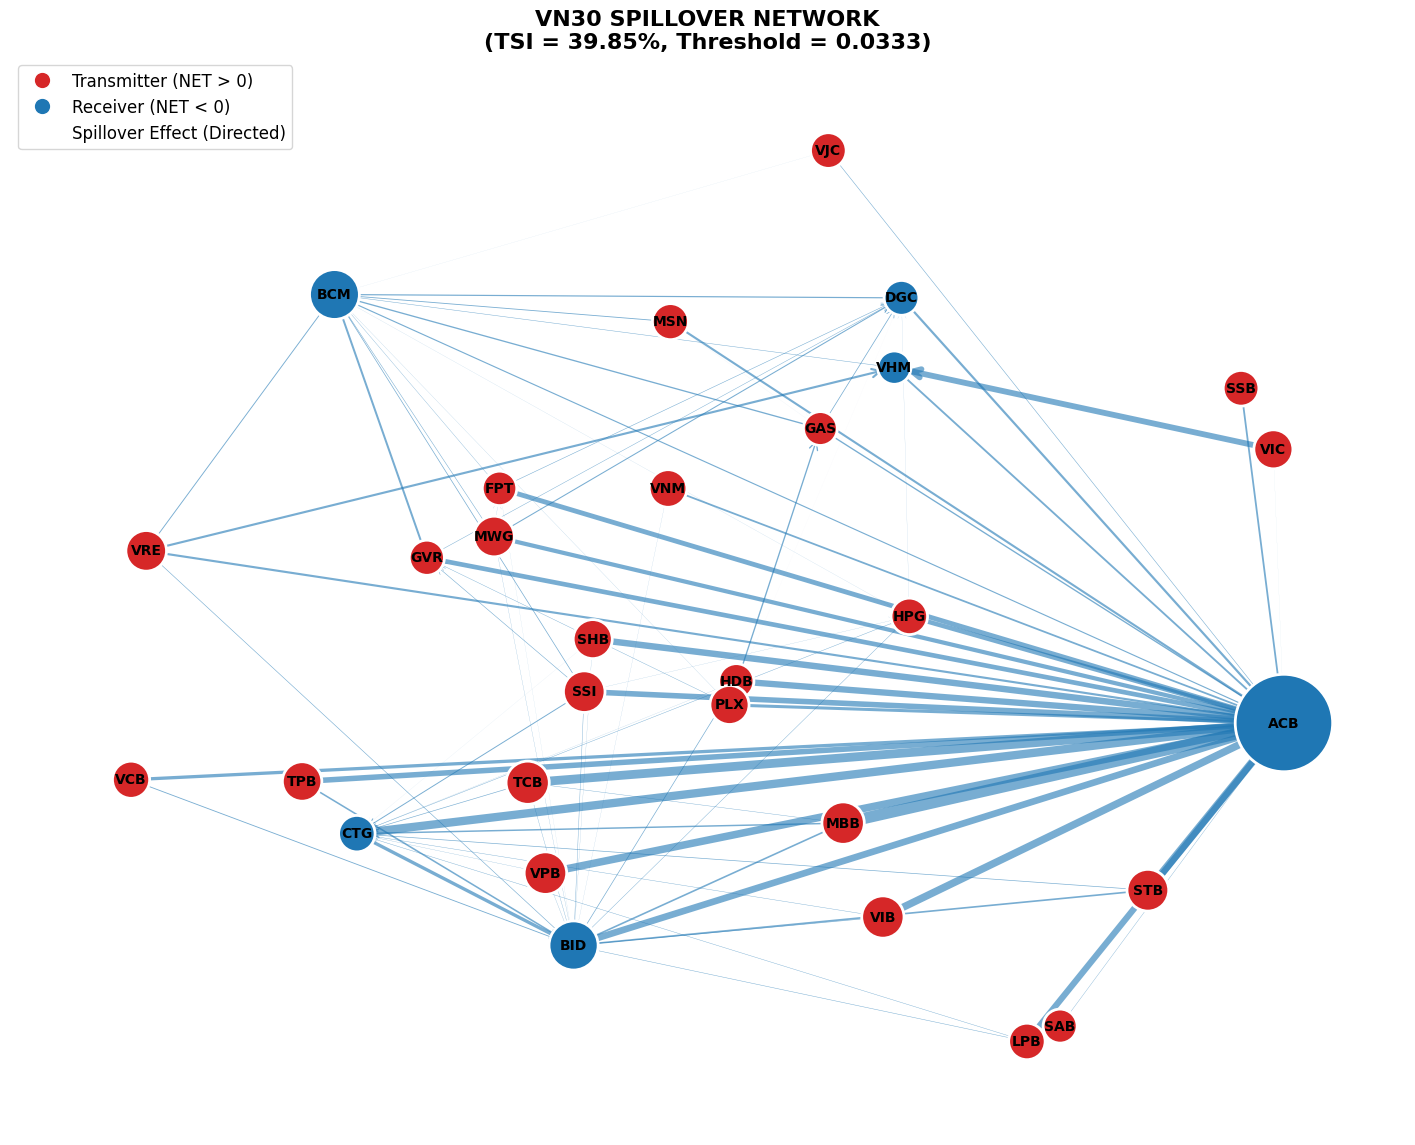

In [10]:
# 1. Tạo Graph từ Spillover (có hướng)
G = nx.DiGraph()

# 2. Add Edges (dựa trên Spillover)
threshold = spillover_df.values.mean() # lọc nhiễu
edges_data = []

for i in spillover_df.index:
  for j in spillover_df.columns:
    if i != j:
      value = spillover_df.loc[i, j]

      if value > threshold:
        # màu cạnh: luôn là direction (không cần âm/dương nữa)
        edge_color = '#1f77b4'

        # độ dày cạnh
        width = (value - threshold) * 20

        G.add_edge(i, j, weight=value, color=edge_color, width=width)

# 3. Node Properties
node_colors = []
node_sizes = []
node_labels = {}

for node in G.nodes():
  node_labels[node] = node

  if net[node] > 0:
    node_colors.append('#d62728') # đỏ = transmitter
  else:
    node_colors.append('#1f77b4') # xanh = receiver

  node_sizes.append(abs(net[node]) * 800 + 500)

# 4. Vẽ graph
plt.figure(figsize=(18, 14))

pos = nx.spring_layout(G, k=0.5, iterations=100, seed=42)

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors='white',
    linewidths=2
)

# Labels
nx.draw_networkx_labels(
    G, pos,
    labels=node_labels,
    font_size=10,
    font_weight='bold'
)

# Edges
edge_color_list = [G[u][v]['color'] for u, v in G.edges()]
edge_width_list = [G[u][v]['width'] for u, v in G.edges()]

nx.draw_networkx_edges(
    G, pos,
    edge_color=edge_color_list,
    width=edge_width_list,
    alpha=0.6,
    arrows=True,
    arrowstyle='->',
    arrowsize=15
)

# 5. Legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Transmitter (NET > 0)',
           markerfacecolor='#d62728', markersize=12),
    Line2D([0], [0], marker='o', color='w',
           label='Receiver (NET < 0)',
           markerfacecolor='#1f77b4', markersize=12),
    Line2D([0], [0], marker='o', color='w',
           label='Spillover Effect (Directed)',)
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True)

plt.title(
    f"VN30 SPILLOVER NETWORK\n(TSI = {tsi:.2f}%, Threshold = {threshold:.4f})",
    fontsize=16,
    fontweight='bold'
)

plt.axis('off')
plt.show()